In [197]:
from pathlib import Path
import random
import shutil
import zipfile

from urllib.request import urlretrieve

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

from sklearn.decomposition import PCA

In [198]:
# ========================================================
# 下載資料集
# ========================================================
DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(exist_ok=True)

TIN_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
TIN_ZIP = DATA_ROOT / "tiny-imagenet-200.zip"
OUT_DIR = DATA_ROOT / "tiny-3class"

# class mapping: {wnid: (class_name, max_images)}
CLASS_INFO = {
    "n02099712": ("Labrador_Retriever", 400),
    "n02504458": ("African_Elephant", 400),
    "n01443537": ("Goldfish", 200),
}

# ========================================================
# Step 1 — Download tiny-imagenet zip
# ========================================================
if not OUT_DIR.exists():
    if not TIN_ZIP.exists():
        print("Downloading Tiny-ImageNet...")
        urlretrieve(TIN_URL, TIN_ZIP)
        print("Download complete.")
    else:
        print("Zip already exists.")
    
# ========================================================
# Step 2 — Selective extraction
# ========================================================

    print("\nExtracting ONLY selected categories...\n")

    with zipfile.ZipFile(TIN_ZIP, "r") as z:

        for wnid, (class_name, max_count) in CLASS_INFO.items():

            # output folder for images
            class_folder = OUT_DIR / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            prefix = f"tiny-imagenet-200/train/{wnid}/images/"
            img_files = sorted([
                f for f in z.namelist()
                if f.startswith(prefix) and f.lower().endswith(".jpeg")
            ])

            img_files = img_files[:max_count]  # limit number

            # extract limited images
            for f in img_files:
                z.extract(f, OUT_DIR)
                extracted = OUT_DIR / f
                # move to final location
                shutil.move(str(extracted), str(class_folder / Path(f).name))

            print(f"✔ {class_name}: {len(img_files)} images extracted")

            # remove intermediate tiny-imagenet-200 folder if exists
            temp_root = OUT_DIR / "tiny-imagenet-200"
            if temp_root.exists():
                shutil.rmtree(temp_root)
    print("\n Extraction complete!")
    print(f"Dataset ready at: {OUT_DIR}")

In [199]:
'''
CNN架構:捲積>池化>捲積>池化>捲積>池化>平坦層>全聯接層'''
class MyCNN(nn.Module):
    def __init__(
        self,
        k = 3,            # kernel size
        s = 1,            # stride
        f1 = 32, f2 = 64, f3 = 128     # filters
    ):
        super(MyCNN, self).__init__()

        # Conv layers
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=k, stride=s, padding=k//2)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=k, stride=s, padding=k//2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=k, stride=s, padding=k//2)

        # 最後 feature map 是 8x8（64→32→16→8）
        self.input_size = 64
        self.flat_dim = self._get_flat_dim(self.input_size)

        # Fully connected layers
        self.fc1 = nn.Linear(self.flat_dim, 128)   # 高階特徵
        self.fc2 = nn.Linear(128, 2)               # 2-node latent layer
        self.fc3 = nn.Linear(2, 3)                 # 分 3 類（Elephant/Golfish/Labrador）

    def _get_flat_dim(self, input_size):
        # 這裡根據卷積層和池化層計算最終特徵圖的尺寸
        x = torch.randn(1, 3, input_size, input_size)  # 假設是 RGB 圖像
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        return x.numel()  # 返回最終特徵圖的大小

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        # Flatten
        x = x.view(x.size(0), -1)

        # 128 維特徵
        x = F.relu(self.fc1(x))

        # 2 維 latent feature
        latent2d = self.fc2(x)

        # 最後分類
        out = self.fc3(latent2d)

        return out, latent2d, x


In [200]:
# =======================
# Training model
# =======================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs, _, _ = model(images)
        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(train_loader), correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # 不需要計算梯度 → 加速 & 省顯存
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _, _ = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(val_loader), correct / total


# =======================
# Training entire model
# =======================
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=20):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    return history


In [201]:
def plot_learning_curves(history):
    epochs = len(history["train_loss"])

    plt.figure(figsize=(14,5))

    # ----- Loss -----
    plt.subplot(1,2,1)
    plt.plot(range(epochs), history["train_loss"], label="Train Loss")
    plt.plot(range(epochs), history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)

    # ----- Accuracy -----
    plt.subplot(1,2,2)
    plt.plot(range(epochs), history["train_acc"], label="Train Acc")
    plt.plot(range(epochs), history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)

    plt.show()


In [202]:
def plot_confusion_matrix(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _, _ = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


In [203]:
def show_samples(images, labels, preds, title):
    plt.figure(figsize=(12, 6))
    plt.suptitle(title, fontsize=16)
    plt.subplots_adjust(top=0.85)
    # 計算實際可顯示的圖片數量，防止超出範圍
    num_samples = min(9, len(images))  # 最多顯示 9 張，或者根據實際數量顯示

    for i in range(num_samples):
        plt.subplot(3, 3, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * np.array([0.229, 0.224, 0.225]) +
               np.array([0.485, 0.456, 0.406]))
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.axis("off")
        plt.title(f"True:{class_names[labels[i]]}\nPredict:{class_names[preds[i]]}")

    plt.show()

# Task 1

In [204]:
# ========================================================
# resized to 64 × 64
# ========================================================

# 1. 定義 transform：Resize + ToTensor + Normalize
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 2. 用 ImageFolder 建立 Dataset
#   - root 底下每個子資料夾視為一個 class
#   - 我們現在是：tiny-3class/Labrador_Retriever/images/*.JPEG
#     ImageFolder 會遞迴往下找圖片，所以 OK
dataset = datasets.ImageFolder(
    root=str(OUT_DIR),
    transform=transform
)

class_names = list(dataset.class_to_idx.keys())

In [205]:
# ===== Train/Val split =====

# 設定隨機種子，確保每次 split 一樣（可重現）
torch.manual_seed(42)

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Total samples:", dataset_size)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# 建立 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 測試一個 batch
train_images, train_labels = next(iter(train_loader))
print("Train batch shape:", train_images.shape)
print("Train batch labels:", train_labels[:10])

Total samples: 1000
Train samples: 800
Val samples: 200
Train batch shape: torch.Size([32, 3, 64, 64])
Train batch labels: tensor([2, 2, 2, 0, 2, 2, 0, 0, 2, 2])


In [206]:
# =======================
# 參數設定
# =======================
kernal = 3
stride = 1
filter1 = 16
filter2 = 32
filter3 = 64

Epoch [1/20] Train Loss: 1.0741, Train Acc: 39.75% | Val Loss: 0.9787, Val Acc: 41.50%
Epoch [2/20] Train Loss: 0.8773, Train Acc: 60.25% | Val Loss: 0.7811, Val Acc: 66.50%
Epoch [3/20] Train Loss: 0.7703, Train Acc: 65.12% | Val Loss: 0.6990, Val Acc: 72.00%
Epoch [4/20] Train Loss: 0.6568, Train Acc: 73.00% | Val Loss: 0.7191, Val Acc: 62.00%
Epoch [5/20] Train Loss: 0.6523, Train Acc: 71.25% | Val Loss: 0.6723, Val Acc: 69.50%
Epoch [6/20] Train Loss: 0.6456, Train Acc: 71.12% | Val Loss: 0.5509, Val Acc: 77.50%
Epoch [7/20] Train Loss: 0.5652, Train Acc: 75.25% | Val Loss: 0.5525, Val Acc: 77.00%
Epoch [8/20] Train Loss: 0.5232, Train Acc: 79.25% | Val Loss: 0.5685, Val Acc: 74.00%
Epoch [9/20] Train Loss: 0.5256, Train Acc: 79.38% | Val Loss: 0.5384, Val Acc: 75.50%
Epoch [10/20] Train Loss: 0.4996, Train Acc: 79.75% | Val Loss: 0.5087, Val Acc: 78.00%
Epoch [11/20] Train Loss: 0.4939, Train Acc: 79.75% | Val Loss: 0.4595, Val Acc: 78.50%
Epoch [12/20] Train Loss: 0.4446, Train A

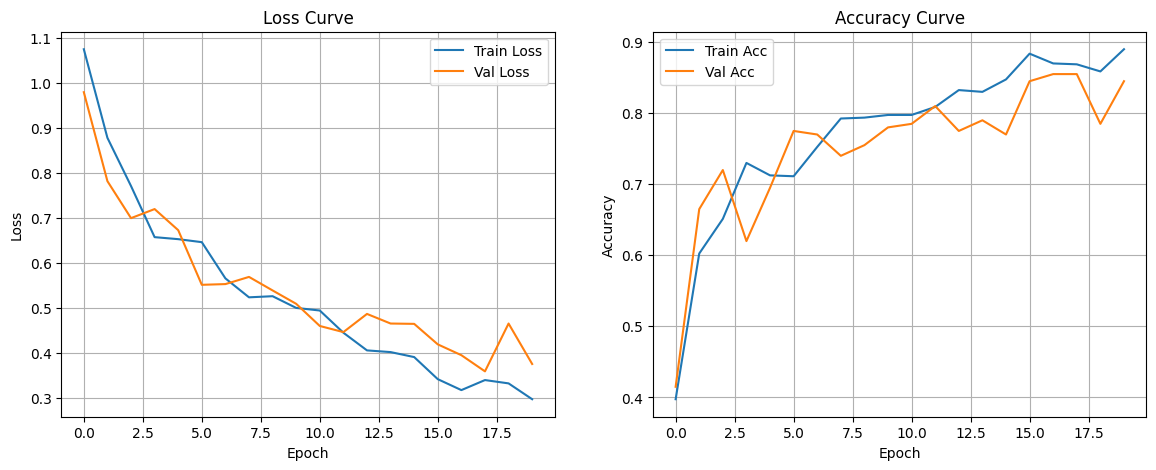

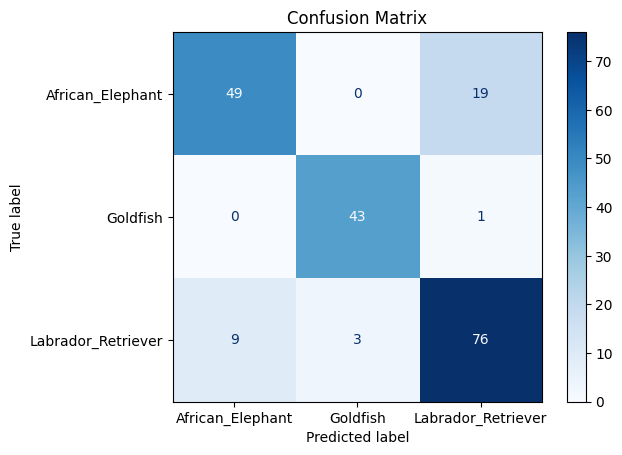

In [207]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyCNN(
    k = kernal,
    s = stride,
    f1 = filter1,f2 = filter2,f3 = filter3
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20
)

plot_learning_curves(history)

plot_confusion_matrix(
    model,
    val_loader,
    device,
    class_names=list(dataset.class_to_idx.keys())
)


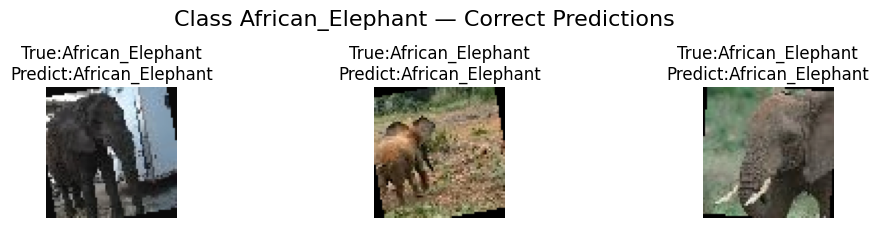

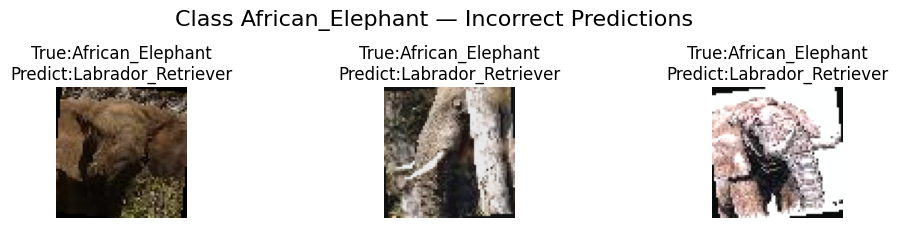

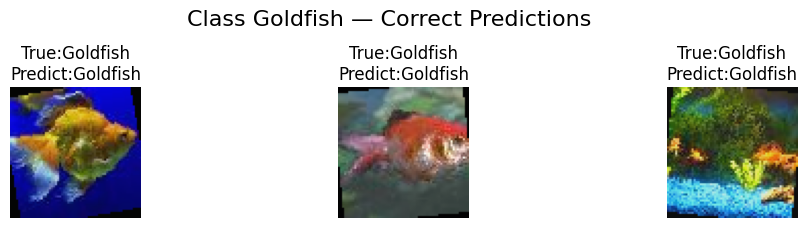

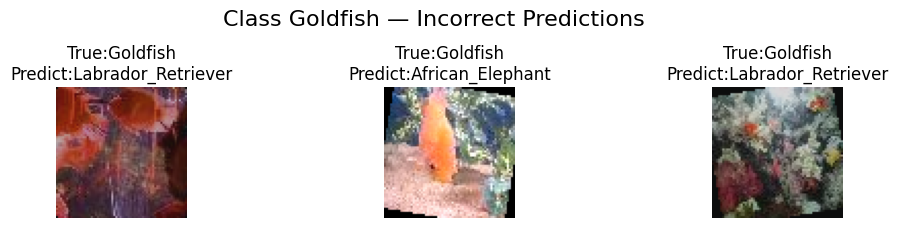

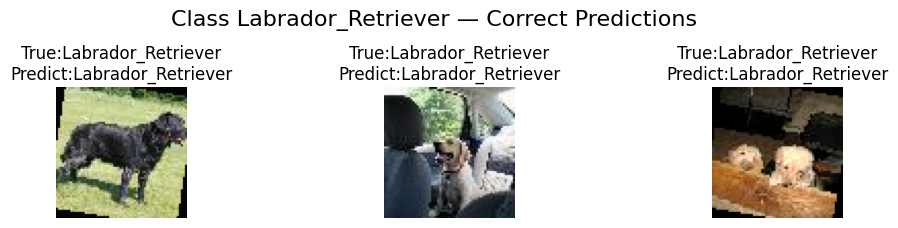

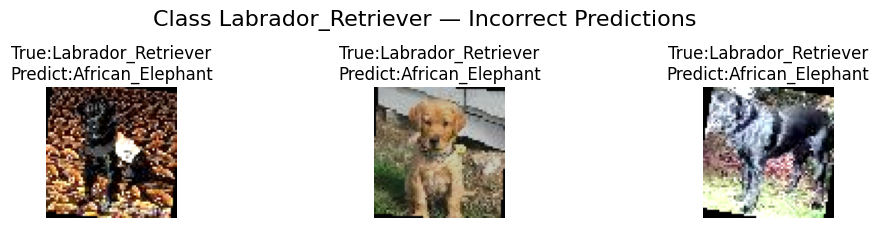

In [208]:
# 收集所有結果
correct = {c: [] for c in range(3)}
wrong   = {c: [] for c in range(3)}

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        out, _, _ = model(images)
        _, preds = out.max(1)

        for i in range(len(labels)):
            lbl = labels[i].item()
            pred = preds[i].item()

            if lbl == pred and len(correct[lbl]) < 3:
                correct[lbl].append((images[i].cpu(), lbl, pred))

            if lbl != pred and len(wrong[lbl]) < 3:
                wrong[lbl].append((images[i].cpu(), lbl, pred))


# 顯示結果（每類 3 張）
for c in range(3):
    # 顯示正確預測的圖片
    imgs = [x[0] for x in correct[c]]
    lbls = [x[1] for x in correct[c]]
    preds = [x[2] for x in correct[c]]
    show_samples(imgs, lbls, preds, f"Class {class_names[c]} — Correct Predictions")

    # 顯示錯誤預測的圖片
    imgs = [x[0] for x in wrong[c]]
    lbls = [x[1] for x in wrong[c]]
    preds = [x[2] for x in wrong[c]]
    show_samples(imgs, lbls, preds, f"Class {class_names[c]} — Incorrect Predictions")


# Task 2

In [209]:
class AugmentedGoldfishDataset(Dataset):
    def __init__(self, dataset, target_class='Goldfish', target_num=400, transform=None):
        self.dataset = dataset
        self.target_class = target_class
        self.target_num = target_num
        self.transform = transform
        
        # 篩選出金魚類別的所有圖片
        self.goldfish_images = [
            img for img, label in dataset.imgs if dataset.classes[label] == self.target_class
        ]
        self.current_num = len(self.goldfish_images)

        # 需要增加的圖片數量
        self.images_to_generate = self.target_num - self.current_num
        
    def __len__(self):
        return len(self.dataset) + self.images_to_generate

    def __getitem__(self, idx):
        if idx < len(self.dataset):
            # 直接返回原始資料集中的圖片
            return self.dataset[idx]
        else:
            # 動態增強金魚圖片，並返回
            img_name = random.choice(self.goldfish_images)
            img = Image.open(img_name)

            if self.transform:
                img = self.transform(img)
                
            # 回傳增強後的圖片
            label = self.dataset.class_to_idx[self.target_class]
            return img, label

In [210]:
# 使用 AugmentedGoldfishDataset 來包裝原始的 dataset
augmented_dataset = AugmentedGoldfishDataset(dataset, target_class='Goldfish', target_num=400, transform=transform)

# ===== Train/Val split =====

# 設定隨機種子，確保每次 split 一樣（可重現）
torch.manual_seed(42)

dataset_size = len(augmented_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(augmented_dataset, [train_size, val_size])

print("Total samples:", dataset_size)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# 建立 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 測試一個 batch
train_images, train_labels = next(iter(train_loader))
print("Train batch shape:", train_images.shape)
print("Train batch labels:", train_labels[:10])

Total samples: 1200
Train samples: 960
Val samples: 240
Train batch shape: torch.Size([32, 3, 64, 64])
Train batch labels: tensor([2, 2, 1, 1, 1, 2, 2, 0, 1, 1])


In [211]:
# =======================
# 參數設定
# =======================
kernal = 3
stride = 1
filter1 = 16
filter2 = 32
filter3 = 64

Epoch [1/20] Train Loss: 0.9215, Train Acc: 51.46% | Val Loss: 0.6545, Val Acc: 72.92%
Epoch [2/20] Train Loss: 0.6907, Train Acc: 66.98% | Val Loss: 0.5569, Val Acc: 72.50%
Epoch [3/20] Train Loss: 0.6138, Train Acc: 73.96% | Val Loss: 0.5490, Val Acc: 75.00%
Epoch [4/20] Train Loss: 0.5465, Train Acc: 76.98% | Val Loss: 0.6088, Val Acc: 72.92%
Epoch [5/20] Train Loss: 0.5446, Train Acc: 76.46% | Val Loss: 0.5411, Val Acc: 76.25%
Epoch [6/20] Train Loss: 0.5067, Train Acc: 79.38% | Val Loss: 0.4999, Val Acc: 77.08%
Epoch [7/20] Train Loss: 0.4529, Train Acc: 80.94% | Val Loss: 0.4867, Val Acc: 75.83%
Epoch [8/20] Train Loss: 0.4348, Train Acc: 82.81% | Val Loss: 0.4760, Val Acc: 77.50%
Epoch [9/20] Train Loss: 0.4247, Train Acc: 81.04% | Val Loss: 0.4540, Val Acc: 77.92%
Epoch [10/20] Train Loss: 0.3781, Train Acc: 85.10% | Val Loss: 0.4408, Val Acc: 83.33%
Epoch [11/20] Train Loss: 0.3193, Train Acc: 87.40% | Val Loss: 0.4183, Val Acc: 83.75%
Epoch [12/20] Train Loss: 0.3035, Train A

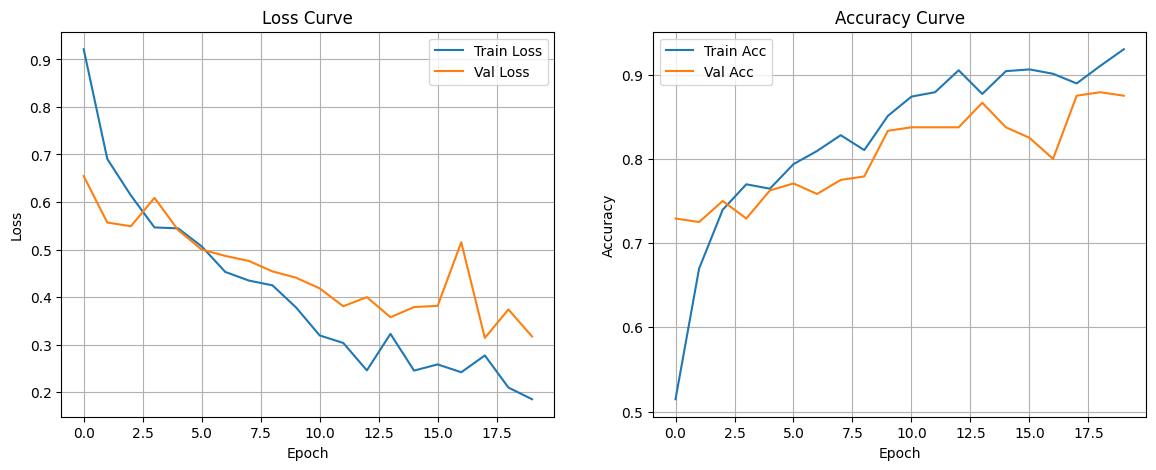

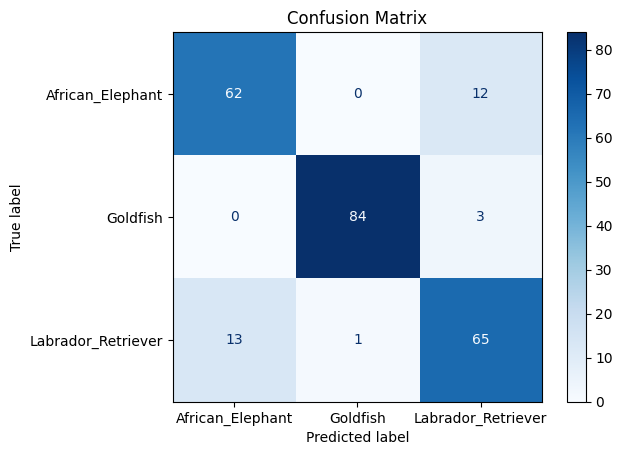

In [212]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyCNN(
    k = kernal,
    s = stride,
    f1 = filter1,f2 = filter2,f3 = filter3
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20
)

plot_learning_curves(history)

plot_confusion_matrix(
    model,
    val_loader,
    device,
    class_names=list(dataset.class_to_idx.keys())
)


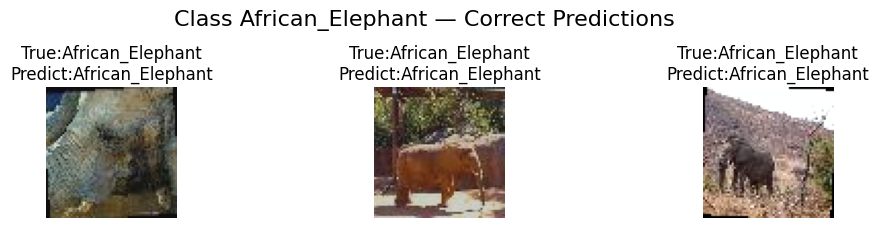

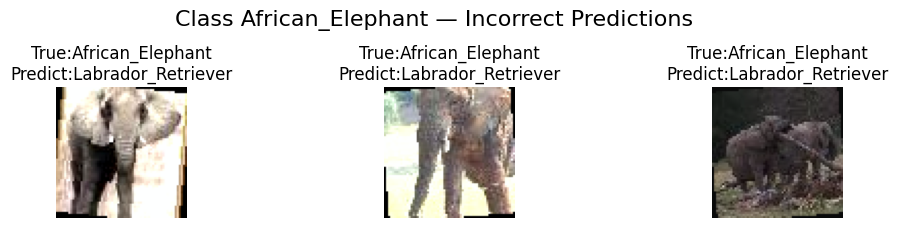

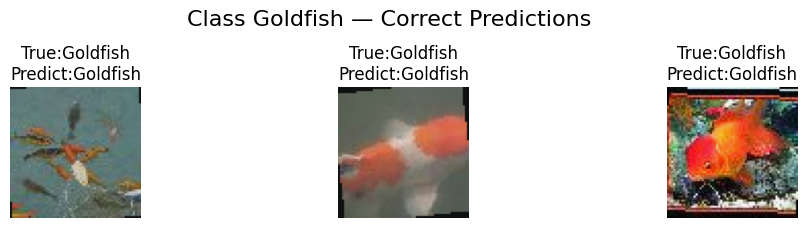

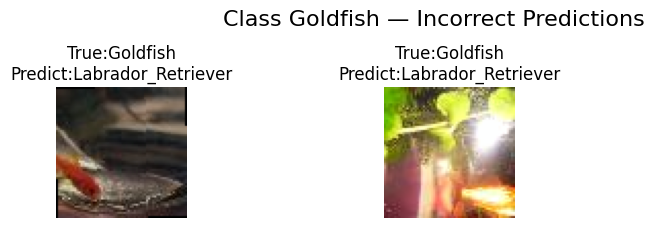

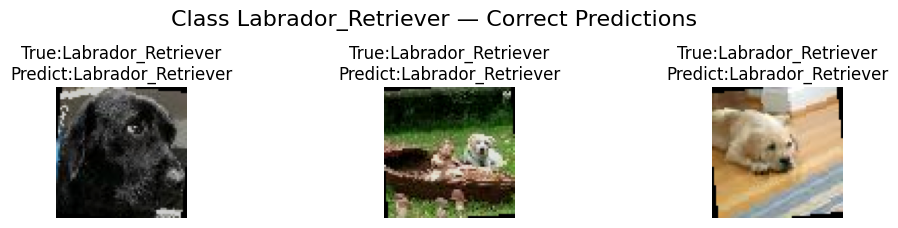

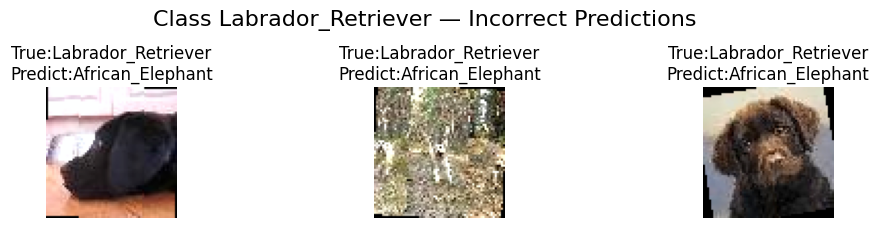

In [218]:
# 收集所有結果
correct = {c: [] for c in range(3)}
wrong   = {c: [] for c in range(3)}

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        out, _, _ = model(images)
        _, preds = out.max(1)

        for i in range(len(labels)):
            lbl = labels[i].item()
            pred = preds[i].item()

            if lbl == pred and len(correct[lbl]) < 3:
                correct[lbl].append((images[i].cpu(), lbl, pred))

            if lbl != pred and len(wrong[lbl]) < 3:
                wrong[lbl].append((images[i].cpu(), lbl, pred))


# 顯示結果（每類 3 張）
for c in range(3):
    # 顯示正確預測的圖片
    imgs = [x[0] for x in correct[c]]
    lbls = [x[1] for x in correct[c]]
    preds = [x[2] for x in correct[c]]
    show_samples(imgs, lbls, preds, f"Class {class_names[c]} — Correct Predictions")

    # 顯示錯誤預測的圖片
    imgs = [x[0] for x in wrong[c]]
    lbls = [x[1] for x in wrong[c]]
    preds = [x[2] for x in wrong[c]]
    show_samples(imgs, lbls, preds, f"Class {class_names[c]} — Incorrect Predictions")


In [214]:
# 提取特徵點
def extract_latents(model, loader, device):
    model.eval()
    lat2_list = []
    lat128_list = []
    label_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            out, latent2d, latent128 = model(images)

            lat2_list.append(latent2d.cpu())
            lat128_list.append(latent128.cpu())
            label_list.append(labels)

    lat2 = torch.cat(lat2_list, dim=0)
    lat128 = torch.cat(lat128_list, dim=0)
    labels = torch.cat(label_list, dim=0)
    
    return lat2.numpy(), lat128.numpy(), labels.numpy()

In [215]:
def compute_pca(lat128, n_components=2):
    pca = PCA(n_components=n_components)
    lat_pca = pca.fit_transform(lat128)
    return lat_pca

In [216]:
def plot_latent_comparison(lat2d, pca2d, labels, class_names):
    colors = ['blue', 'orange', 'green']

    plt.figure(figsize=(14, 6))

    # ---- left: direct latent2d ----
    plt.subplot(1, 2, 1)
    for i, cls in enumerate(class_names):
        mask = (labels == i)
        plt.scatter(lat2d[mask, 0], lat2d[mask, 1], c=colors[i], label=cls, s=15)
    plt.title("Direct 2D Latent (from fc2)")
    plt.xlabel("Latent dim 1")
    plt.ylabel("Latent dim 2")
    plt.legend()
    plt.grid(True)

    # ---- right: PCA of 128D latent ----
    plt.subplot(1, 2, 2)
    for i, cls in enumerate(class_names):
        mask = (labels == i)
        plt.scatter(pca2d[mask, 0], pca2d[mask, 1], c=colors[i], label=cls, s=15)
    plt.title("PCA on 128D Latent → 2D")
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


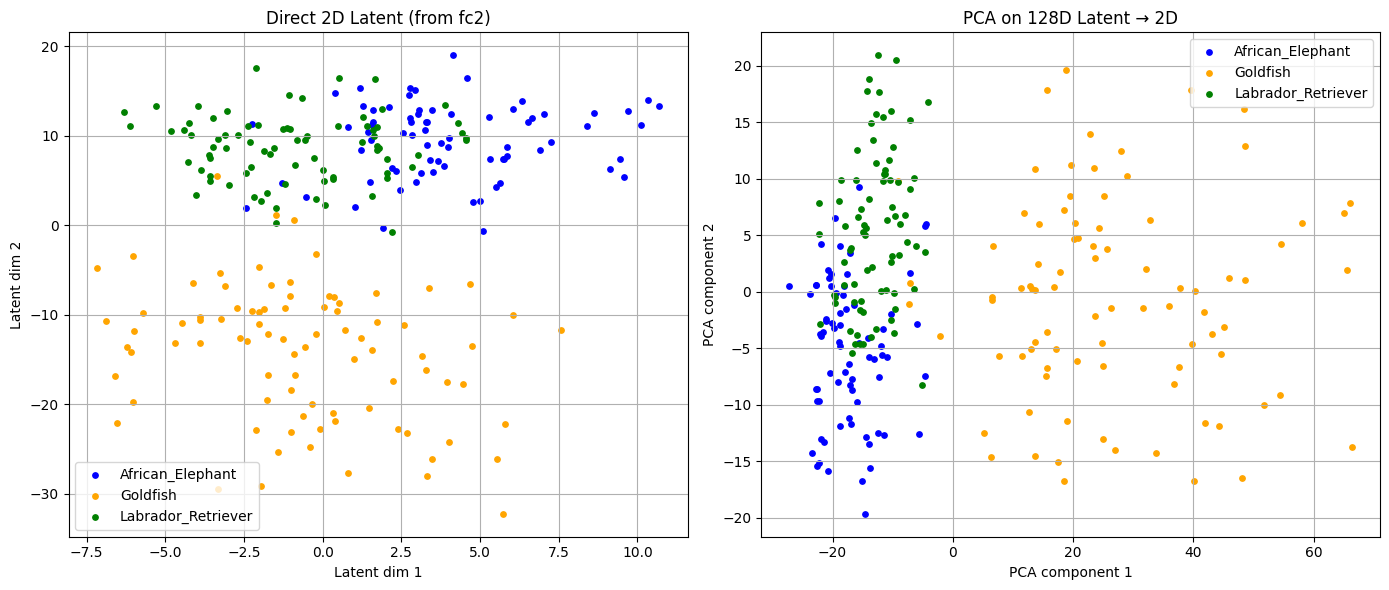

In [217]:
# step 1: extract latent features
lat2d, lat128, labels = extract_latents(model, val_loader, device)

# step 2: PCA (128D → 2D)
lat128_pca = compute_pca(lat128)

# step 3: plot comparison
plot_latent_comparison(lat2d, lat128_pca, labels, class_names)

